# Notebook 03 - MLP with Embeddings

## MLP Baseline Overview

This notebook trains the first deep learning baseline model. The model uses embeddings for categorical variables and combines them with numerical features in a fully connected neural network.

The goal is to create a stable baseline for comparison. It is not expected to be the best model, especially because the delay classes are imbalanced.


In [18]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from tqdm import tqdm

## Environment and Output Folders

This section defines the processed data path, model output folder, results folder, and available compute device.


In [19]:
BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "generated" / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Loading Processed Data

We load the metadata, category cardinalities, and class weights created in Notebook 02. These files define the model inputs and the three target classes.


In [20]:
with open(PROCESSED_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

with open(PROCESSED_DIR / "category_cardinalities.json", "r") as f:
    category_cardinalities = json.load(f)

with open(PROCESSED_DIR / "class_weights.json", "r") as f:
    class_weights_dict = json.load(f)

categorical_cols = metadata["categorical_cols"]
numeric_cols = metadata["numeric_cols"]
num_classes = metadata["num_classes"]
class_names = metadata["class_names"]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numeric_cols)
print("Num classes:", num_classes)
print("Category cardinalities:", category_cardinalities)

Categorical columns: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_STATE_ABR', 'ROUTE', 'DEP_TIME_BLK', 'ARR_TIME_BLK']
Numerical columns: ['DISTANCE', 'CRS_DEP_MINUTES_OF_DAY', 'dep_time_sin', 'dep_time_cos', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend']
Num classes: 3
Category cardinalities: {'OP_UNIQUE_CARRIER': 16, 'ORIGIN': 363, 'ORIGIN_STATE_ABR': 53, 'DEST': 363, 'DEST_STATE_ABR': 53, 'ROUTE': 7454, 'DEP_TIME_BLK': 20, 'ARR_TIME_BLK': 20}


The train, validation, and test arrays are loaded from `.npz` files. Categorical and numerical inputs stay separate because the model handles them differently.


In [21]:
train_data = np.load(PROCESSED_DIR / "train_data.npz")
val_data = np.load(PROCESSED_DIR / "val_data.npz")
test_data = np.load(PROCESSED_DIR / "test_data.npz")

X_train_cat = train_data["X_cat"]
X_train_num = train_data["X_num"]
y_train = train_data["y"]

X_val_cat = val_data["X_cat"]
X_val_num = val_data["X_num"]
y_val = val_data["y"]

X_test_cat = test_data["X_cat"]
X_test_num = test_data["X_num"]
y_test = test_data["y"]

print("Train categorical:", X_train_cat.shape)
print("Train numerical:", X_train_num.shape)
print("Train target:", y_train.shape)

print("Validation categorical:", X_val_cat.shape)
print("Validation numerical:", X_val_num.shape)
print("Validation target:", y_val.shape)

print("Test categorical:", X_test_cat.shape)
print("Test numerical:", X_test_num.shape)
print("Test target:", y_test.shape)

Train categorical: (14411707, 8)
Train numerical: (14411707, 9)
Train target: (14411707,)
Validation categorical: (3088223, 8)
Validation numerical: (3088223, 9)
Validation target: (3088223,)
Test categorical: (3088224, 8)
Test numerical: (3088224, 9)
Test target: (3088224,)


## Dataset and DataLoader Preparation

The custom dataset converts numpy arrays into PyTorch tensors. The DataLoaders then batch the data for training, validation, and testing.


In [22]:
class FlightDelayDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

In [23]:
batch_size = 4096

train_dataset = FlightDelayDataset(X_train_cat, X_train_num, y_train)
val_dataset = FlightDelayDataset(X_val_cat, X_val_num, y_val)
test_dataset = FlightDelayDataset(X_test_cat, X_test_num, y_test)

class_counts = np.bincount(y_train, minlength=num_classes)
class_percentages = class_counts / class_counts.sum() * 100

print("Class counts:", class_counts)
print("Class percentages:", np.round(class_percentages, 4))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Class counts: [11450162  2309070   652475]
Class percentages: [79.4504 16.0222  4.5274]
Train batches: 3519
Validation batches: 754
Test batches: 754


## Embedding-Based Model Architecture

Each categorical feature receives its own embedding layer. The embedding outputs are concatenated with the numerical features before passing through dense layers.


In [24]:
embedding_dims = []

for col in categorical_cols:
    cardinality = category_cardinalities[col]
    emb_dim = min(50, max(4, cardinality // 2))
    embedding_dims.append((cardinality, emb_dim))

embedding_dims

[(16, 8),
 (363, 50),
 (53, 26),
 (363, 50),
 (53, 26),
 (7454, 50),
 (20, 10),
 (20, 10)]

The MLP uses fully connected layers for multiclass classification. The output has one logit for each delay class.


In [25]:
class MLPWithEmbeddings(nn.Module):
    def __init__(
        self,
        embedding_dims,
        num_numeric_features,
        num_classes,
        hidden_dims=[256, 128, 64],
        dropout=0.3
    ):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=cardinality, embedding_dim=emb_dim)
            for cardinality, emb_dim in embedding_dims
        ])

        total_embedding_dim = sum(emb_dim for _, emb_dim in embedding_dims)
        input_dim = total_embedding_dim + num_numeric_features

        layers = []

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, num_classes))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_num):
        embedded_features = []

        for i, embedding_layer in enumerate(self.embeddings):
            embedded_features.append(embedding_layer(x_cat[:, i]))

        x_emb = torch.cat(embedded_features, dim=1)
        x = torch.cat([x_emb, x_num], dim=1)

        return self.mlp(x)

In [26]:
model = MLPWithEmbeddings(
    embedding_dims=embedding_dims,
    num_numeric_features=len(numeric_cols),
    num_classes=num_classes,
    hidden_dims=[256, 128, 64],
    dropout=0.3
).to(device)

model

MLPWithEmbeddings(
  (embeddings): ModuleList(
    (0): Embedding(16, 8)
    (1): Embedding(363, 50)
    (2): Embedding(53, 26)
    (3): Embedding(363, 50)
    (4): Embedding(53, 26)
    (5): Embedding(7454, 50)
    (6-7): 2 x Embedding(20, 10)
  )
  (mlp): Sequential(
    (0): Linear(in_features=239, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [27]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 515967
Trainable parameters: 515967


In [28]:
print("num_classes:", num_classes)
print("class_weights_dict:", class_weights_dict)

num_classes: 3
class_weights_dict: {'0': 0.4195488529623715, '1': 2.0804489830682193, '2': 7.3625845179253355}


## Loss Function and Optimizer

The model uses `CrossEntropyLoss` with moderated class weights. Macro F1 is the main metric because it gives equal importance to each class, while accuracy can be misleading on imbalanced data.


In [29]:
class_weights = np.array(
    [class_weights_dict[str(i)] for i in range(num_classes)],
    dtype=np.float32
)

class_weights = np.log1p(class_weights)
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

In [30]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

## Training Loop

The training function updates the model weights and records loss, accuracy, Macro F1, and weighted F1 for each epoch.


In [31]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch=None, num_epochs=None):
    model.train()

    total_loss = 0
    all_preds = []
    all_targets = []
    processed_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Training Epoch {epoch}/{num_epochs}",
        leave=True
    )

    for batch_idx, (x_cat, x_num, y) in enumerate(progress_bar):
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        batch_size_actual = y.size(0)

        processed_samples += batch_size_actual
        total_loss += loss.item() * batch_size_actual

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

        current_loss = total_loss / processed_samples
        current_progress = (processed_samples / len(dataloader.dataset)) * 100

        progress_bar.set_postfix({
            "progress": f"{current_progress:.2f}%",
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{current_loss:.4f}"
        })

    avg_loss = total_loss / processed_samples

    accuracy = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    return avg_loss, accuracy, macro_f1, weighted_f1

## Validation Monitoring

The evaluation function measures performance without updating the model. Validation Macro F1 is used to decide when to save the best checkpoint.


In [32]:
def evaluate_model(model, dataloader, criterion, device, split_name="Validation"):
    model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []
    processed_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Evaluating {split_name}",
        leave=True
    )

    with torch.no_grad():
        for batch_idx, (x_cat, x_num, y) in enumerate(progress_bar):
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y = y.to(device)

            outputs = model(x_cat, x_num)
            loss = criterion(outputs, y)

            batch_size_actual = y.size(0)

            processed_samples += batch_size_actual
            total_loss += loss.item() * batch_size_actual

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

            current_loss = total_loss / processed_samples
            current_progress = (processed_samples / len(dataloader.dataset)) * 100

            progress_bar.set_postfix({
                "progress": f"{current_progress:.2f}%",
                "batch_loss": f"{loss.item():.4f}",
                "avg_loss": f"{current_loss:.4f}"
            })

    avg_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    return avg_loss, accuracy, macro_f1, weighted_f1, np.array(all_targets), np.array(all_preds)

In [33]:
def print_prediction_distribution(predictions, title="Prediction Distribution"):
    unique, counts = np.unique(predictions, return_counts=True)

    distribution = {
        int(k): int(v)
        for k, v in zip(unique, counts)
    }

    print(title)
    print(distribution)

The main training loop runs for a fixed maximum number of epochs with early stopping. The best model is selected using validation Macro F1.


In [34]:
num_epochs = 10

best_val_macro_f1 = 0
best_model_path = MODELS_DIR / "mlp_embeddings_best.pt"

patience = 4
epochs_without_improvement = 0

history = []

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()

    print(f"\nStarting epoch {epoch}/{num_epochs}")
    print("-" * 100)

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        epoch=epoch,
        num_epochs=num_epochs
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, y_true_val, y_pred_val = evaluate_model(
        model,
        val_loader,
        criterion,
        device,
        split_name="Validation"
    )
    print_prediction_distribution(
        y_pred_val,
        "Validation Prediction Distribution"
    )

    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "epoch_time_seconds": epoch_time
    })

    print(f"\nEpoch {epoch}/{num_epochs} completed")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_macro_f1:.4f} | Train Weighted F1: {train_weighted_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro F1:   {val_macro_f1:.4f} | Val Weighted F1:   {val_weighted_f1:.4f}")
    print(f"Epoch time: {epoch_time:.2f} seconds")
    print("-" * 100)

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "embedding_dims": embedding_dims,
            "numeric_cols": numeric_cols,
            "categorical_cols": categorical_cols,
            "num_classes": num_classes,
            "best_val_macro_f1": best_val_macro_f1,
            "epoch": epoch
        }, best_model_path)

        print(f"Best model saved with Val Macro F1: {best_val_macro_f1:.4f}")

    else:
        epochs_without_improvement += 1

        print(f"No improvement for {epochs_without_improvement} epoch(s)")

        if epochs_without_improvement >= patience:
            print("Early stopping triggered")
            break

total_training_time = time.time() - start_time

print("\nTraining completed")
print(f"Total training time: {total_training_time:.2f} seconds")
print(f"Best validation Macro F1: {best_val_macro_f1:.4f}")


Starting epoch 1/10
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 754/754 [00:45<00:00, 16.49it/s, progress=100.00%, batch_loss=0.9496, avg_loss=0.9520]


Validation Prediction Distribution
{0: 2473706, 1: 588255, 2: 26262}

Epoch 1/10 completed
Train Loss: 0.9640 | Train Acc: 0.7239 | Train Macro F1: 0.3863 | Train Weighted F1: 0.7141
Val Loss:   0.9520 | Val Acc:   0.7235 | Val Macro F1:   0.4011 | Val Weighted F1:   0.7174
Epoch time: 376.94 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.4011

Starting epoch 2/10
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 754/754 [00:43<00:00, 17.42it/s, progress=100.00%, batch_loss=0.9474, avg_loss=0.9487]


Validation Prediction Distribution
{0: 2493932, 1: 588098, 2: 6193}

Epoch 2/10 completed
Train Loss: 0.9545 | Train Acc: 0.7233 | Train Macro F1: 0.3983 | Train Weighted F1: 0.7169
Val Loss:   0.9487 | Val Acc:   0.7295 | Val Macro F1:   0.3904 | Val Weighted F1:   0.7198
Epoch time: 367.05 seconds
----------------------------------------------------------------------------------------------------
No improvement for 1 epoch(s)

Starting epoch 3/10
----------------------------------------------------------------------------------------------------


...

Validation Prediction Distribution
{0: 2416008, 1: 635746, 2: 36469}

Epoch 8/10 completed
Train Loss: 0.9445 | Train Acc: 0.7187 | Train Macro F1: 0.4112 | Train Weighted F1: 0.7178
Val Loss:   0.9421 | Val Acc:   0.7198 | Val Macro F1:   0.4127 | Val Weighted F1:   0.7190
Epoch time: 349.91 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.4127

Starting epoch 9/10
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 754/754 [00:36<00:00, 20.41it/s, progress=100.00%, batch_loss=0.9409, avg_loss=0.9418]


Validation Prediction Distribution
{0: 2442728, 1: 610307, 2: 35188}

Epoch 9/10 completed
Train Loss: 0.9437 | Train Acc: 0.7189 | Train Macro F1: 0.4122 | Train Weighted F1: 0.7181
Val Loss:   0.9418 | Val Acc:   0.7242 | Val Macro F1:   0.4125 | Val Weighted F1:   0.7211
Epoch time: 338.72 seconds
----------------------------------------------------------------------------------------------------
No improvement for 1 epoch(s)

Starting epoch 10/10
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 754/754 [00:37<00:00, 19.85it/s, progress=100.00%, batch_loss=0.9378, avg_loss=0.9415]


Validation Prediction Distribution
{0: 2403494, 1: 625271, 2: 59458}

Epoch 10/10 completed
Train Loss: 0.9431 | Train Acc: 0.7184 | Train Macro F1: 0.4132 | Train Weighted F1: 0.7180
Val Loss:   0.9415 | Val Acc:   0.7169 | Val Macro F1:   0.4202 | Val Weighted F1:   0.7184
Epoch time: 343.41 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.4202

Training completed
Total training time: 3593.84 seconds
Best validation Macro F1: 0.4202


The training history is saved so the loss and Macro F1 curves can be reviewed after training.


In [35]:
history_df = pd.DataFrame(history)

history_path = RESULTS_DIR / "mlp_embeddings_training_history.csv"
history_df.to_csv(history_path, index=False)

history_df

,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,epoch_time_seconds
0,1,0.964025,0.723887,0.386254,0.714062,0.952000,0.723506,0.401097,0.717411,376.941680
1,2,0.954471,0.723306,0.398332,0.716865,0.948740,0.729473,0.390435,0.719751,367.051279
2,3,0.951426,0.721714,0.402214,0.717149,0.946520,0.727929,0.409180,0.721596,378.662846
3,4,0.949340,0.721058,0.405337,0.717510,0.945163,0.726107,0.411608,0.721218,372.445958
4,5,0.947768,0.720193,0.407064,0.717539,0.944295,0.720925,0.410217,0.718763,360.179414
5,6,0.946440,0.719819,0.408637,0.717758,0.943258,0.726853,0.409046,0.721739,357.281564
6,7,0.945408,0.719062,0.410089,0.717668,0.942671,0.721083,0.406490,0.718749,349.155039
7,8,0.944524,0.718722,0.411213,0.717762,0.942097,0.719784,0.412654,0.718972,349.912041
8,9,0.943687,0.718881,0.412207,0.718060,0.941817,0.724206,0.412514,0.721147,338.716743
9,10,0.943114,0.718421,0.413156,0.717987,0.941469,0.716895,0.420204,0.718416,343.412238


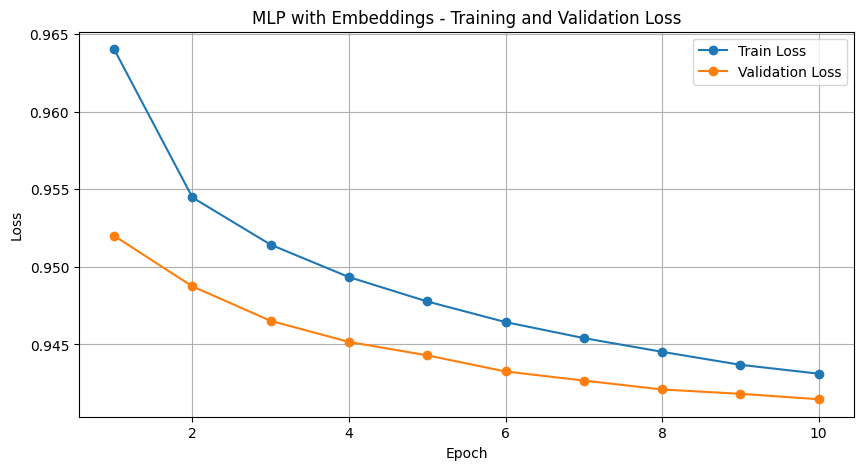

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP with Embeddings - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

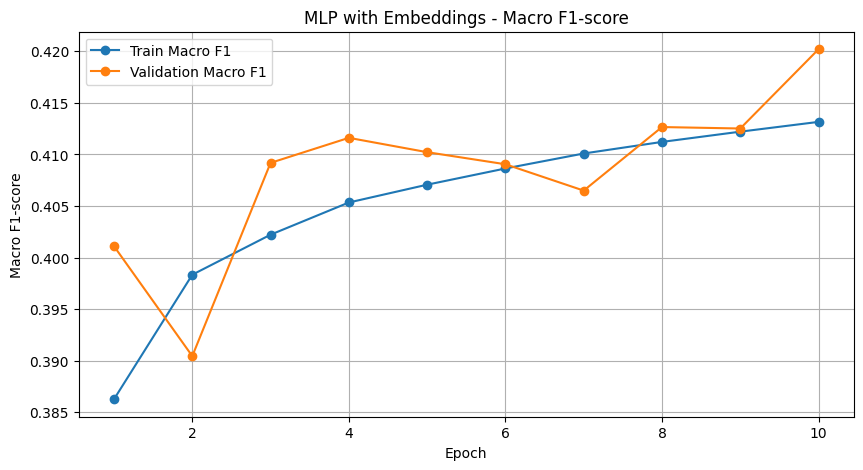

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("MLP with Embeddings - Macro F1-score")
plt.legend()
plt.grid(True)
plt.show()

## Test Evaluation

After training, the best saved checkpoint is loaded and evaluated on the test set. The test set represents later months that were not used for training or validation.


In [38]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = MLPWithEmbeddings(
    embedding_dims=checkpoint["embedding_dims"],
    num_numeric_features=len(checkpoint["numeric_cols"]),
    num_classes=checkpoint["num_classes"],
    hidden_dims=[256, 128, 64],
    dropout=0.3
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])

print("Best model loaded")
print("Best validation Macro F1:", checkpoint["best_val_macro_f1"])
print("Best epoch:", checkpoint["epoch"])

Best model loaded
Best validation Macro F1: 0.42020369785374356
Best epoch: 10


C:\Users\of_de\AppData\Local\Temp\ipykernel_30020\3727690503.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device

In [39]:
test_loss, test_acc, test_macro_f1, test_weighted_f1, y_true, y_pred = evaluate_model(
    best_model,
    test_loader,
    criterion,
    device,
    split_name="Test"
)

print("Test results")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))
print("Test macro F1:", round(test_macro_f1, 4))
print("Test weighted F1:", round(test_weighted_f1, 4))

Evaluating Test: 100%|██████████| 754/754 [00:36<00:00, 20.86it/s, progress=100.00%, batch_loss=0.9205, avg_loss=0.9418]


Test results
Test loss: 0.9418
Test accuracy: 0.7162
Test macro F1: 0.4192
Test weighted F1: 0.7179


## Confusion Matrix and Final Results

The classification report and confusion matrix show how the model performs for each delay class, not just overall accuracy.


In [40]:
target_names = [class_names[str(i)] for i in range(num_classes)]

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     On time       0.84      0.82      0.83   2453607
       Delay       0.28      0.36      0.32    494801
  Long delay       0.18      0.08      0.11    139816

    accuracy                           0.72   3088224
   macro avg       0.44      0.42      0.42   3088224
weighted avg       0.72      0.72      0.72   3088224



The MLP performs best on the majority `On time` class. Its performance is limited on `Long delay`, which shows why accuracy alone is not enough for this project.


In [41]:
with open(RESULTS_DIR / "mlp_embeddings_classification_report.txt", "w") as f:
    f.write(report)

In [42]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

cm_df

,On time,Delay,Long delay
On time,2024151,398182,31274
Delay,299900,176909,17992
Long delay,77356,51626,10834


The confusion matrix shows that many delayed and long-delay flights are still predicted as on time. This makes the MLP useful as a baseline, but not as the strongest final model.


In [43]:
cm_df.to_csv(RESULTS_DIR / "mlp_embeddings_confusion_matrix.csv")

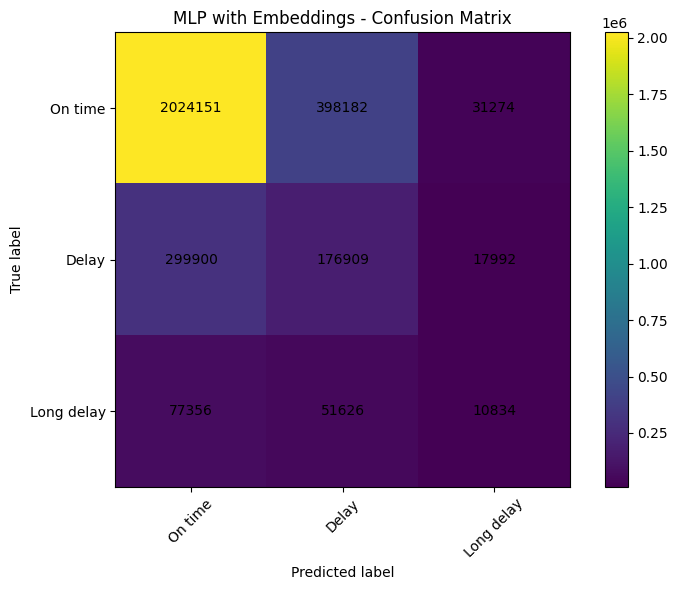

In [44]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("MLP with Embeddings - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(num_classes), target_names, rotation=45)
plt.yticks(np.arange(num_classes), target_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

The final result dictionary stores the test metrics and model configuration for comparison with the other models.


In [45]:
mlp_results = {
    "model_name": "MLP with Embeddings",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "best_val_macro_f1": float(best_val_macro_f1),
    "total_training_time_seconds": float(total_training_time),
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "loss_function": "CrossEntropyLoss with softened class weights",
    "architecture": {
        "embedding_dims": embedding_dims,
        "hidden_dims": [256, 128, 64],
        "dropout": 0.3,
        "num_numeric_features": len(numeric_cols),
        "num_categorical_features": len(categorical_cols),
        "num_classes": num_classes
    }
}

with open(RESULTS_DIR / "mlp_embeddings_results.json", "w") as f:
    json.dump(mlp_results, f, indent=4)

mlp_results

{'model_name': 'MLP with Embeddings',
 'test_loss': 0.9418475892728412,
 'test_accuracy': 0.716234962230719,
 'test_macro_f1': 0.4192354228963017,
 'test_weighted_f1': 0.7179429732255903,
 'best_val_macro_f1': 0.42020369785374356,
 'total_training_time_seconds': 3593.8418111801147,
 'num_epochs': 10,
 'batch_size': 4096,
 'optimizer': 'AdamW',
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'loss_function': 'CrossEntropyLoss with softened class weights',
 'architecture': {'embedding_dims': [(16, 8),
   (363, 50),
   (53, 26),
   (363, 50),
   (53, 26),
   (7454, 50),
   (20, 10),
   (20, 10)],
  'hidden_dims': [256, 128, 64],
  'dropout': 0.3,
  'num_numeric_features': 9,
  'num_categorical_features': 8,
  'num_classes': 3}}

In [46]:
print("Notebook 03 completed")
print("Model: MLP with Embeddings")

print("\nSaved files:")
print(best_model_path)
print(RESULTS_DIR / "mlp_embeddings_training_history.csv")
print(RESULTS_DIR / "mlp_embeddings_classification_report.txt")
print(RESULTS_DIR / "mlp_embeddings_confusion_matrix.csv")
print(RESULTS_DIR / "mlp_embeddings_results.json")

print("\nFinal Test Metrics:")
print(f"Accuracy:    {test_acc:.4f}")
print(f"Macro F1:    {test_macro_f1:.4f}")
print(f"Weighted F1: {test_weighted_f1:.4f}")

Notebook 03 completed
Model: MLP with Embeddings

Saved files:
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\models\mlp_embeddings_best.pt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\mlp_embeddings_training_history.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\mlp_embeddings_classification_report.txt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\mlp_embeddings_confusion_matrix.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\mlp_embeddings_results.json

Final Test Metrics:
Accuracy:    0.7162
Macro F1:    0.4192
Weighted F1: 0.7179


## MLP Model Conclusion

The MLP with embeddings provides a clear deep learning baseline. It reaches reasonable overall accuracy, but Macro F1 and the Long delay results show that the model still struggles with the minority class.
